<div style="text-align: center; font-family: 'Segoe UI', Arial, sans-serif; margin-bottom: 25px;">
    <h2 style="letter-spacing: 1px; font-weight: 600; font-size: 1.6em; color: #111; text-transform: uppercase;">
        AGH University of Krakow
    </h2>
</div>

<div style="text-align: center; font-family: 'Segoe UI', Arial, sans-serif; margin-bottom: 10px;">
    <h1 style="font-size: 2.8em; font-weight: 600; color: #1a1a1a; margin: 0;">
        Time over threshold
    </h1>
</div>

<div style="text-align: center; font-family: 'Segoe UI', Arial, sans-serif; margin-bottom: 15px;">
    <h1 style="font-size: 1.3em; font-weight: 600; color: #5a5a5a; margin: 0;">
        Wojciech Miskowicz and Tymon Rys
    </h1>
</div>

<div style="font-family: 'Segoe UI', Arial, sans-serif; font-size: 1.1em; line-height: 1.6; border-left: 4px solid #dcdcdc; padding-left: 20px; margin: 20px 0; color: #333; text-align: justify;">
    The goal of this project is to estimate time over threshold of a pulse signal coming from pixel detecor based
    on mathematical model provided in [1]. The terget device is a Zynq UltraScale+ ZCU106 Evaluation Platform.    
</div>


<div style="font-family: 'Segoe UI', Arial, sans-serif; font-size: 1.1em; line-height: 1.6; border-left: 4px solid #dcdcdc; padding-left: 20px; margin: 20px 0; color: #333; text-align: justify;">
    The project can work in regular mode with data incoming from ADC and debug mode when data is passed via Python     script writing to BRAM.
    In regular mode the pulse is coverted by ADC12DL3200 chip. Data is sent on both rising and falling 800 MHz         clock edges (DDR) via 4 paralell channels. This creates a need for the FPGA to process several samples per         clock cycle. 
    In order to simulate these conditions an additional bram_controller was added. It's job is to read test data
    and stream several samples per clock sample in order to simulate real scenario conditions.
</div>

In [310]:
from pynq import Overlay

tot_ov = Overlay("design_1_wrapper.xsa")

# Init memory map
tot_ov.ip_dict
tot_calc = tot_ov.tot_calculator_0
bram_controller = tot_ov.adc_bram_simulator_0
bram = tot_ov.axi_bram_ctrl_0


BRAM_BASE_ADDR = 0xA002_0000

# ToT Calculator IP
TOT_THR_ADDR = 0x0
TOT_RESULT_TOT_ADDR = 0x4
TOT_RESULT_T_LEAD_LO_ADDR = 0x8
TOT_RESULT_T_LEAD_HI_ADDR = 0xC

# ADC BRAM Simulator
ADC_SIM_CSR_ADDR = 0x0
ADC_SIM_START_BIT = 0x1
ADC_SIM_BRAM_ADDR_START_ADDR = 0x4
ADC_SIM_BRAM_ADDR_STOP_ADDR = 0x8

In [ ]:
# Pulse parameters
SAMPLING_RATE = 2_403_846_153 # 2.4 GHz sampling freq
DURATION = 150e-9              # 15 ns window
PEAK_TIME = 13e-9             # 4 ns (Tp)
PEAK_AMP = 0.7              # Volts or arbitrary units

THRESHOLD = 2000

Clearing BRAM storage array cleanly...
Writing 360 samples safely to BRAM storage...
Safe hardware write completed successfully!


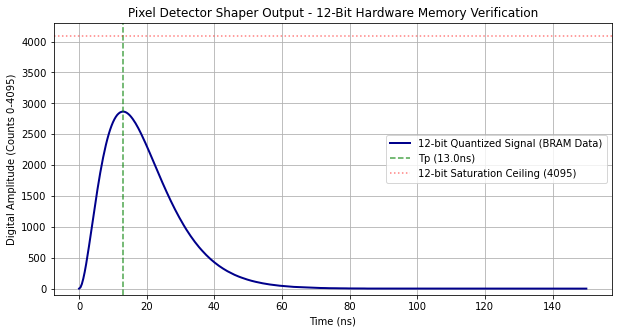

In [311]:
import numpy as np
import matplotlib.pyplot as plt
from pynq import Overlay

def generate_shaper_pulse(t, peaking_time, amplitude, order=2):
    """
    Generates a semi-Gaussian pulse shape.
    """
    # Prevent divide by zero if peaking_time is invalid
    if peaking_time <= 0:
        return np.zeros_like(t)
    
    pulse = amplitude * (t / peaking_time)**order * np.exp(order * (1 - t / peaking_time))
    pulse[t < 0] = 0
    return pulse


# --- Hardware Safety Thresholds ---
BRAM_SIZE_BYTES = 8192
BYTES_PER_SAMPLE = 4  # Each 32-bit slot uses 4 bytes
MAX_BRAM_SAMPLES = BRAM_SIZE_BYTES // BYTES_PER_SAMPLE  # Exactly 2048 slots

# --- Signal Generation ---
num_samples = int(DURATION * SAMPLING_RATE)

# CRITICAL SAFETY CHECK: Ensure data array fits within physical memory allocations
if num_samples > MAX_BRAM_SAMPLES:
    print(f"WARNING: Generated samples ({num_samples}) exceeds BRAM capacity ({MAX_BRAM_SAMPLES})!")
    print(f"Truncating signal length to fit safely within hardware limits.")
    num_samples = MAX_BRAM_SAMPLES

time = np.linspace(0, DURATION, num_samples)
analog_signal = generate_shaper_pulse(time, PEAK_TIME, PEAK_AMP)

# --- Quantization (Normalized to Max 12-bit) ---
# 12-bit max value = 2^12 - 1 = 4095
MAX_12BIT_VAL = 4095

# Normalize and scale
digital_signal = analog_signal * MAX_12BIT_VAL

# HARD SAFETY CLIP: Prevent any mathematical float overflow/underflow before casting
digital_signal = np.clip(digital_signal, 0, MAX_12BIT_VAL)
digital_signal = digital_signal.astype(np.uint32)

# --- Hardware Safe Write Loop ---
print("Clearing BRAM storage array cleanly...")
for offset in range(0, BRAM_SIZE_BYTES, BYTES_PER_SAMPLE):
    bram.write(offset, 0)

print(f"Writing {len(digital_signal)} samples safely to BRAM storage...")
for index, sample_value in enumerate(digital_signal):
    # Byte offset increases by 4 for every 32-bit address entry
    byte_offset = index * BYTES_PER_SAMPLE
    
    # Cast to pure Python int to satisfy PYNQ low-level driver restrictions
    bram.write(byte_offset, int(sample_value))

print("Safe hardware write completed successfully!")

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(time * 1e9, digital_signal, label="12-bit Quantized Signal (BRAM Data)", color='darkblue', linewidth=2)
plt.axvline(PEAK_TIME * 1e9, color='green', linestyle='--', alpha=0.7, label=f"Tp ({PEAK_TIME*1e9:.1f}ns)")
plt.axhline(MAX_12BIT_VAL, color='red', linestyle=':', alpha=0.5, label="12-bit Saturation Ceiling (4095)")
plt.title("Pixel Detector Shaper Output - 12-Bit Hardware Memory Verification")
plt.xlabel("Time (ns)")
plt.ylabel("Digital Amplitude (Counts 0-4095)")
plt.ylim(-100, 4300)
plt.legend()
plt.grid(True)
plt.show()

Reading raw data from physical BRAM cells...

             BRAM MEMORY & SIGNAL REPORT             
BRAM Base Address:       0xa0020000
BRAM Total Capacity:     8192 Bytes (2048 Slots)
--------------------------------------------------
Data Detected:           215 active samples
Data Start Address:      0xa0020004 (Offset: 0x4)
Data Stop Address:       0xa002035c (Offset: 0x35c)
--------------------------------------------------
             TIME OVER THRESHOLD (ToT)               
--------------------------------------------------
Peak Amplitude:          2866 counts
Applied Threshold:       2000.00 counts
Samples Over Threshold:  38
Estimated ToT:           3.800 ns



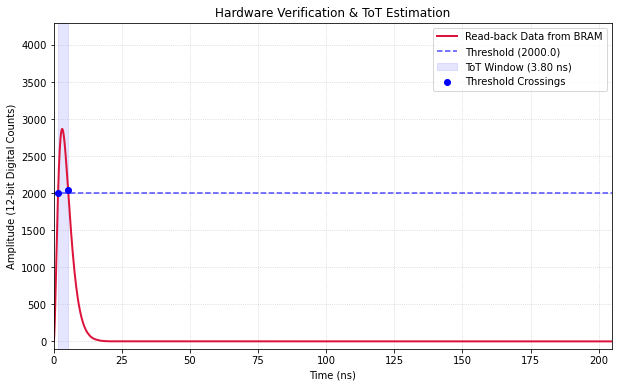

In [312]:
import numpy as np
import matplotlib.pyplot as plt
from pynq import Overlay

# --- Hardware & Address Configuration ---
BRAM_SIZE_BYTES = 8192
BYTES_PER_SAMPLE = 4  # 32-bit words
MAX_BRAM_SAMPLES = BRAM_SIZE_BYTES // BYTES_PER_SAMPLE  # 2048 slots


# --- Read Data from Hardware ---
print("Reading raw data from physical BRAM cells...")
read_samples = []

# Note: Ensure 'bram' MMIO object is initialized prior to this block in your Jupyter notebook
for index in range(MAX_BRAM_SAMPLES):
    byte_offset = index * BYTES_PER_SAMPLE
    # Read the 32-bit value and append it
    sample_value = bram.read(byte_offset)
    read_samples.append(sample_value)

# Convert to a standard NumPy array for processing
read_data = np.array(read_samples, dtype=np.uint32)

# --- Dynamic Address Tracking ---
# Find where your actual pulse data ends (ignoring trailing zeros)
non_zero_indices = np.where(read_data > 0)[0]

if len(non_zero_indices) > 0:
    start_index = non_zero_indices[0]
    stop_index = non_zero_indices[-1]
    
    # Calculate the full absolute physical addresses
    full_start_address = BRAM_BASE_ADDR + (start_index * BYTES_PER_SAMPLE)
    full_stop_address = BRAM_BASE_ADDR + (stop_index * BYTES_PER_SAMPLE)
    
    active_samples_count = (stop_index - start_index) + 1
else:
    # Fallback if the entire memory is zeros
    start_index, stop_index = 0, 0
    full_start_address = BRAM_BASE_ADDR
    full_stop_address = BRAM_BASE_ADDR
    active_samples_count = 0

# --- Time over Threshold (ToT) Estimation ---
# Define threshold: Here we use 50% of peak amplitude, but you can hardcode a fixed count value (e.g., 2000)
peak_amplitude = np.max(read_data) 

# Find indices where data is strictly above the threshold
above_threshold_indices = np.where(read_data > THRESHOLD)[0]

if len(above_threshold_indices) > 0:
    tot_start_idx = above_threshold_indices[0]
    tot_stop_idx = above_threshold_indices[-1]
    
    # Calculate time duration
    sample_period = 1.0 / SAMPLING_RATE
    tot_samples = (tot_stop_idx - tot_start_idx) + 1
    tot_seconds = tot_samples * sample_period
    tot_ns = tot_seconds * 1e9
else:
    tot_start_idx, tot_stop_idx = 0, 0
    tot_samples = 0
    tot_ns = 0.0

# --- Print Hardware Memory Diagnostics & ToT Report ---
print("\n" + "="*50)
print("             BRAM MEMORY & SIGNAL REPORT             ")
print("="*50)
print(f"BRAM Base Address:       {hex(BRAM_BASE_ADDR)}")
print(f"BRAM Total Capacity:     {BRAM_SIZE_BYTES} Bytes ({MAX_BRAM_SAMPLES} Slots)")
print("-"*50)
if active_samples_count > 0:
    print(f"Data Detected:           {active_samples_count} active samples")
    print(f"Data Start Address:      {hex(full_start_address)} (Offset: {hex(start_index * BYTES_PER_SAMPLE)})")
    print(f"Data Stop Address:       {hex(full_stop_address)} (Offset: {hex(stop_index * BYTES_PER_SAMPLE)})")
else:
    print("Data Status:             BRAM is completely empty (all zeros).")
print("-"*50)
print("             TIME OVER THRESHOLD (ToT)               ")
print("-"*50)
print(f"Peak Amplitude:          {peak_amplitude} counts")
print(f"Applied Threshold:       {THRESHOLD:.2f} counts")
print(f"Samples Over Threshold:  {tot_samples}")
print(f"Estimated ToT:           {tot_ns:.3f} ns")
print("="*50 + "\n")

# --- Reconstruction & Plotting ---
# Recreate the time axis based on the samples read
time_axis = np.arange(len(read_data)) / SAMPLING_RATE
time_axis_ns = time_axis * 1e9

plt.figure(figsize=(10, 6))
plt.plot(time_axis_ns, read_data, label="Read-back Data from BRAM", color='crimson', linewidth=2)

# Visual additions for ToT tracking
if tot_samples > 0:
    # Draw horizontal threshold line
    plt.axhline(y=THRESHOLD, color='blue', linestyle='--', alpha=0.7, label=f'Threshold ({THRESHOLD:.1f})')
    
    # Highlight the ToT interval
    plt.axvspan(time_axis_ns[tot_start_idx], time_axis_ns[tot_stop_idx], color='blue', alpha=0.1, label=f'ToT Window ({tot_ns:.2f} ns)')
    
    # Marks at crossing limits
    plt.scatter([time_axis_ns[tot_start_idx], time_axis_ns[tot_stop_idx]], 
                [read_data[tot_start_idx], read_data[tot_stop_idx]], 
                color='blue', zorder=5, label='Threshold Crossings')

plt.title("Hardware Verification & ToT Estimation")
plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (12-bit Digital Counts)")
plt.xlim(0, (MAX_BRAM_SAMPLES / SAMPLING_RATE) * 1e9)  # Show the full memory window
plt.ylim(-100, 4300)
plt.legend(loc="upper right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [352]:
from time import sleep

tot = tot_calc.write(TOT_THR_ADDR, THRESHOLD)
bram_controller.write(ADC_SIM_BRAM_ADDR_START_ADDR, int(full_start_address))
bram_controller.write(ADC_SIM_BRAM_ADDR_STOP_ADDR, int(full_stop_address))

bram_controller.write(ADC_SIM_CSR_ADDR, ADC_SIM_START_BIT)
sleep(0.1)
bram_controller.write(ADC_SIM_CSR_ADDR, 0x0)

In [353]:
# --- 1. Read raw 32-bit registers from your AXI IP ---
tot = tot_calc.read(0x04)
t_lead_low = tot_calc.read(0x08)   # Corresponds to t_lead[31:0]
t_lead_high = tot_calc.read(0x0C)  # Corresponds to t_lead[63:32]

# --- 2. Reconstruct the full 64-bit value ---
# Shift the upper 32 bits left, then combine with the lower 32 bits
t_leading = (t_lead_high << 32) | t_lead_low

# --- 3. Print out the results ---
print(f"ToT       = {tot/1000}ns")
print(f"t_leading = {t_leading / 1000_000_000_000}sec")

ToT       = 15.817ns
t_leading = 82.957539976288sec
